In [1]:
import pandas as pd

jobs = pd.read_csv("results_easy_kth/jobs.csv")
print(jobs.columns)
jobs.head()

Index(['job_id', 'workload_name', 'profile', 'submission_time',
       'requested_number_of_resources', 'requested_time', 'success',
       'final_state', 'starting_time', 'execution_time', 'finish_time',
       'waiting_time', 'turnaround_time', 'stretch', 'allocated_resources',
       'consumed_energy', 'metadata'],
      dtype='object')


,job_id,workload_name,profile,submission_time,requested_number_of_resources,requested_time,success,final_state,starting_time,execution_time,finish_time,waiting_time,turnaround_time,stretch,allocated_resources,consumed_energy,metadata
0,job_0_1996093012094528,w0,profile_0,0.0,1,60.0,0,COMPLETED_WALLTIME_REACHED,0.0,60.0,60.0,0.0,60.0,1.0,0,-1.0,NaN
1,job_1_1996093012102051,w0,profile_1,44.0,2,60.0,0,COMPLETED_WALLTIME_REACHED,44.0,60.0,104.0,0.0,60.0,1.0,1-2,-1.0,NaN
2,job_2_1996093012094721,w0,profile_2,122.0,1,60.0,0,COMPLETED_WALLTIME_REACHED,122.0,60.0,182.0,0.0,60.0,1.0,0,-1.0,NaN
3,job_3_1996093012094910,w0,profile_3,241.0,1,60.0,0,COMPLETED_WALLTIME_REACHED,241.0,60.0,301.0,0.0,60.0,1.0,0,-1.0,NaN
4,job_5_1996093012492331,w0,profile_5,2387.0,1,600.0,0,COMPLETED_WALLTIME_REACHED,2387.0,600.0,2987.0,0.0,600.0,1.0,1,-1.0,NaN


In [3]:
start = "starting_time"
finish = "finish_time"
submit = "submission_time"  

if submit in jobs.columns:
    jobs["waiting_time"] = jobs[start] - jobs[submit]
else:
   
    jobs["runtime"] = jobs[finish] - jobs[start]

jobs[["job_id", start, finish] + (["waiting_time"] if "waiting_time" in jobs.columns else ["runtime"])].head()

,job_id,starting_time,finish_time,waiting_time
0,job_0_1996093012094528,0.0,60.0,0.0
1,job_1_1996093012102051,44.0,104.0,0.0
2,job_2_1996093012094721,122.0,182.0,0.0
3,job_3_1996093012094910,241.0,301.0,0.0
4,job_5_1996093012492331,2387.0,2987.0,0.0


In [4]:
col = "waiting_time" if "waiting_time" in jobs.columns else "runtime"
stats = jobs[col].agg(["min", "median", "mean", "max"])
print(stats)

min          0.000000
median       0.000000
mean      1004.292683
max       5005.000000
Name: waiting_time, dtype: float64


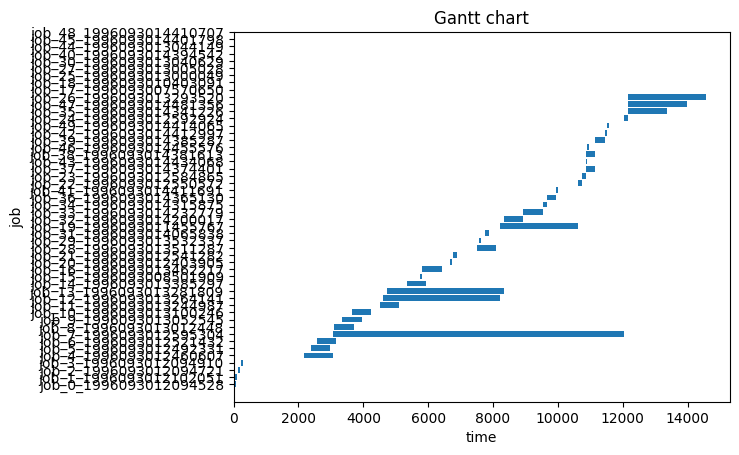

In [5]:
import matplotlib.pyplot as plt

jobs_sorted = jobs.sort_values("starting_time").reset_index(drop=True)

y = range(len(jobs_sorted))
start = jobs_sorted["starting_time"]
duration = jobs_sorted["finish_time"] - jobs_sorted["starting_time"]

plt.figure()
plt.barh(list(y), duration, left=start)
plt.yticks(list(y), jobs_sorted["job_id"])
plt.xlabel("time")
plt.ylabel("job")
plt.title("Gantt chart")
plt.show()

In [6]:
import pandas as pd

sched = pd.read_csv("out/schedule.csv")
print(sched.columns)
sched.head(20)

Index(['batsim_version', 'consumed_joules', 'makespan', 'max_slowdown',
       'max_turnaround_time', 'max_waiting_time', 'mean_slowdown',
       'mean_turnaround_time', 'mean_waiting_time', 'nb_computing_machines',
       'nb_grouped_switches', 'nb_jobs', 'nb_jobs_finished', 'nb_jobs_killed',
       'nb_jobs_rejected', 'nb_jobs_success', 'nb_machine_switches',
       'scheduling_time', 'simulation_time', 'success_rate', 'time_computing',
       'time_idle', 'time_sleeping', 'time_switching_off', 'time_switching_on',
       'time_unavailable'],
      dtype='object')


,batsim_version,consumed_joules,makespan,max_slowdown,max_turnaround_time,max_waiting_time,mean_slowdown,mean_turnaround_time,mean_waiting_time,nb_computing_machines,...,nb_machine_switches,scheduling_time,simulation_time,success_rate,time_computing,time_idle,time_sleeping,time_switching_off,time_switching_on,time_unavailable
0,4.0.0,0.0,11306.611162,27.554146,757.921182,316.742819,1.426614,161.414497,9.925125,32,...,0,0.279256,3.591434,1.0,256361.954,94735.510763,0.0,0.0,0.0,0.0


In [7]:
jobs[["job_id", "allocated_resources"]]

,job_id,allocated_resources
0,job_0_1996093012094528,0
1,job_1_1996093012102051,1-2
2,job_2_1996093012094721,0
3,job_3_1996093012094910,0
4,job_5_1996093012492331,1
5,job_4_1996093012460607,0
6,job_6_1996093012521432,2
7,job_8_1996093013012448,0
8,job_9_1996093013052545,2
9,job_10_1996093013100246,3
